In [1]:
# ============================================================
# CELL 1: IMPORT THƯ VIỆN VÀ CẤU HÌNH CHUNG
# ============================================================

import os
import gc
import json
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import torchvision.models as models

from PIL import Image
from tqdm.auto import tqdm

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Cấu hình seed để kết quả có thể tái lập
# ------------------------------------------------------------
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Giúp kết quả ổn định hơn, nhưng có thể làm train hơi chậm
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

# ------------------------------------------------------------
# Cấu hình thiết bị
# ------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

# ------------------------------------------------------------
# Thư mục output
# ------------------------------------------------------------
OUTPUT_DIR = Path("/kaggle/working/notebook02_baseline")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CKPT_DIR = OUTPUT_DIR / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

PRED_DIR = OUTPUT_DIR / "predictions"
PRED_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("OUTPUT_DIR:", OUTPUT_DIR)

Device: cuda
GPU: Tesla T4
CUDA version: 12.8
OUTPUT_DIR: /kaggle/working/notebook02_baseline


In [2]:
# ============================================================
# CELL 2: TÌM METADATA TỪ NOTEBOOK 01
# ============================================================

INPUT_ROOT = Path("/kaggle/input")
WORKING_ROOT = Path("/kaggle/working")

def find_file_everywhere(filename):
    """
    Tìm file trong /kaggle/working trước, sau đó trong /kaggle/input.
    """
    search_roots = [WORKING_ROOT, INPUT_ROOT]
    
    for root in search_roots:
        matches = list(root.rglob(filename))
        if len(matches) > 0:
            return matches[0]
    
    return None

RSNA_TRAIN_CSV = find_file_everywhere("rsna_train.csv")
RSNA_VAL_CSV = find_file_everywhere("rsna_val.csv")
RSNA_TEST_CSV = find_file_everywhere("rsna_test.csv")

print("RSNA_TRAIN_CSV:", RSNA_TRAIN_CSV)
print("RSNA_VAL_CSV  :", RSNA_VAL_CSV)
print("RSNA_TEST_CSV :", RSNA_TEST_CSV)

assert RSNA_TRAIN_CSV is not None, "Không tìm thấy rsna_train.csv. Hãy add output Notebook 01."
assert RSNA_VAL_CSV is not None, "Không tìm thấy rsna_val.csv. Hãy add output Notebook 01."
assert RSNA_TEST_CSV is not None, "Không tìm thấy rsna_test.csv. Hãy add output Notebook 01."

print("Đã tìm thấy đủ metadata RSNA.")

RSNA_TRAIN_CSV: /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/rsna_train.csv
RSNA_VAL_CSV  : /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/rsna_val.csv
RSNA_TEST_CSV : /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/rsna_test.csv
Đã tìm thấy đủ metadata RSNA.


In [3]:
# ============================================================
# CELL 3: ĐỌC METADATA RSNA
# ============================================================

train_df = pd.read_csv(RSNA_TRAIN_CSV)
val_df = pd.read_csv(RSNA_VAL_CSV)
test_df = pd.read_csv(RSNA_TEST_CSV)

print("Train shape:", train_df.shape)
print("Val shape  :", val_df.shape)
print("Test shape :", test_df.shape)

print("\nTrain label distribution:")
print(train_df["label"].value_counts())

print("\nVal label distribution:")
print(val_df["label"].value_counts())

print("\nTest label distribution:")
print(test_df["label"].value_counts())

display(train_df.head())

Train shape: (18678, 4)
Val shape  : (4003, 4)
Test shape : (4003, 4)

Train label distribution:
label
0    14470
1     4208
Name: count, dtype: int64

Val label distribution:
label
0    3101
1     902
Name: count, dtype: int64

Test label distribution:
label
0    3101
1     902
Name: count, dtype: int64


,patientId,label,num_boxes,image_path
0,9b79a98f-a665-42ab-a74f-1fb5bc355247,0,0,/kaggle/input/competitions/rsna-pneumonia-dete...
1,125a6b00-d20c-413e-b5fb-3728fcfce39f,1,1,/kaggle/input/competitions/rsna-pneumonia-dete...
2,e0a6d43d-5889-4d2a-a853-3b3234ac8fbb,0,0,/kaggle/input/competitions/rsna-pneumonia-dete...
3,64f2b57e-5be6-461a-bdf9-15b85c767182,0,0,/kaggle/input/competitions/rsna-pneumonia-dete...
4,f99e4a69-4026-42c6-883a-c4183a8eff12,0,0,/kaggle/input/competitions/rsna-pneumonia-dete...


In [4]:
# ============================================================
# CELL 4: KIỂM TRA ĐƯỜNG DẪN ẢNH RSNA
# ============================================================

def count_missing_images(df):
    return (~df["image_path"].apply(lambda x: Path(x).exists())).sum()

missing_train = count_missing_images(train_df)
missing_val = count_missing_images(val_df)
missing_test = count_missing_images(test_df)

print("Missing train images:", missing_train)
print("Missing val images  :", missing_val)
print("Missing test images :", missing_test)

Missing train images: 0
Missing val images  : 0
Missing test images : 0


In [5]:
# ============================================================
# CELL 5: SỬA ĐƯỜNG DẪN ẢNH RSNA NẾU CẦN
# ============================================================

def find_dir(root, dirname):
    matches = [p for p in Path(root).rglob(dirname) if p.is_dir()]
    return matches[0] if matches else None

total_missing = missing_train + missing_val + missing_test

if total_missing > 0:
    print("Có ảnh bị missing. Đang tìm lại thư mục stage_2_train_images...")
    
    RSNA_TRAIN_IMG_DIR = find_dir(INPUT_ROOT, "stage_2_train_images")
    
    print("RSNA_TRAIN_IMG_DIR:", RSNA_TRAIN_IMG_DIR)
    assert RSNA_TRAIN_IMG_DIR is not None, "Không tìm thấy stage_2_train_images. Hãy add RSNA dataset."
    
    def fix_rsna_path(patient_id):
        return str(RSNA_TRAIN_IMG_DIR / f"{patient_id}.dcm")
    
    train_df["image_path"] = train_df["patientId"].apply(fix_rsna_path)
    val_df["image_path"] = val_df["patientId"].apply(fix_rsna_path)
    test_df["image_path"] = test_df["patientId"].apply(fix_rsna_path)

print("Missing train images after fix:", count_missing_images(train_df))
print("Missing val images after fix  :", count_missing_images(val_df))
print("Missing test images after fix :", count_missing_images(test_df))

assert count_missing_images(train_df) == 0, "Train vẫn còn ảnh missing."
assert count_missing_images(val_df) == 0, "Val vẫn còn ảnh missing."
assert count_missing_images(test_df) == 0, "Test vẫn còn ảnh missing."

print("Đường dẫn ảnh RSNA đã OK.")

Missing train images after fix: 0
Missing val images after fix  : 0
Missing test images after fix : 0
Đường dẫn ảnh RSNA đã OK.


In [6]:
# ============================================================
# CELL 6: IMPORT PYDICOM ĐỂ ĐỌC ẢNH DICOM
# ============================================================

try:
    import pydicom
    print("pydicom imported successfully.")
except ImportError:
    print("pydicom chưa có. Đang cài đặt...")
    !pip install -q pydicom
    import pydicom
    print("pydicom installed and imported successfully.")

pydicom imported successfully.


In [7]:
# ============================================================
# CELL 7: HÀM ĐỌC DICOM RSNA
# ============================================================

def read_dicom_as_pil(path):
    """
    Đọc ảnh DICOM và chuyển thành PIL Image RGB.
    
    Vì ResNet50/ViT pretrained ImageNet nhận ảnh 3 kênh,
    ta chuyển grayscale X-quang thành RGB bằng cách lặp lại 3 kênh.
    """
    dicom = pydicom.dcmread(path)
    img = dicom.pixel_array.astype(np.float32)
    
    # Normalize intensity về [0, 255]
    img = img - np.min(img)
    max_val = np.max(img)
    if max_val > 0:
        img = img / max_val
    img = (img * 255).astype(np.uint8)
    
    # Chuyển grayscale sang PIL RGB
    pil_img = Image.fromarray(img).convert("RGB")
    return pil_img

In [8]:
# ============================================================
# CELL 8: TEST ĐỌC THỬ ẢNH RSNA
# ============================================================

sample_paths = train_df["image_path"].sample(n=3, random_state=SEED).tolist()

for p in sample_paths:
    img = read_dicom_as_pil(p)
    print(Path(p).name, "size:", img.size, "mode:", img.mode)

c485ba23-a466-4d67-b73a-3c1298260718.dcm size: (1024, 1024) mode: RGB
ca3d47d8-af70-4742-b53c-2cb77aaf63b7.dcm size: (1024, 1024) mode: RGB
67ee3f8f-2619-4800-bedf-15794758d155.dcm size: (1024, 1024) mode: RGB


In [9]:
# ============================================================
# CELL 9: TRANSFORM CHO TRAIN / VAL / TEST
# ============================================================

IMG_SIZE = 224

# Normalize theo ImageNet pretrained
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomRotation(degrees=7),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.10, contrast=0.10),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transforms ready.")

Transforms ready.


In [10]:
# ============================================================
# CELL 10: DATASET CLASS CHO RSNA
# ============================================================

class RSNADataset(Dataset):
    """
    Dataset cho bài toán binary classification:
    Pneumonia / Non-pneumonia.
    """
    
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        image_path = row["image_path"]
        label = float(row["label"])
        
        image = read_dicom_as_pil(image_path)
        
        if self.transform is not None:
            image = self.transform(image)
        
        label = torch.tensor(label, dtype=torch.float32)
        
        return {
            "image": image,
            "label": label,
            "patientId": row["patientId"]
        }

In [11]:
# ============================================================
# CELL 11: TẠO DATALOADER
# ============================================================

BATCH_SIZE = 16
NUM_WORKERS = 2

train_dataset = RSNADataset(train_df, transform=train_transform)
val_dataset = RSNADataset(val_df, transform=eval_transform)
test_dataset = RSNADataset(test_df, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 1168
Val batches  : 251
Test batches : 251


In [12]:
# ============================================================
# CELL 12: TEST MỘT BATCH DỮ LIỆU
# ============================================================

batch = next(iter(train_loader))

print("Image batch shape:", batch["image"].shape)
print("Label batch shape:", batch["label"].shape)
print("Patient IDs example:", batch["patientId"][:3])

Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])
Patient IDs example: ['16968a9f-ba45-4f51-a584-ac57612de5c3', 'e2e89418-6c0e-4f50-a2d9-6cd5e58feef0', '2232fe6c-e152-4875-9b6d-1706a3b1652c']


In [13]:
# ============================================================
# CELL 13: HÀM TÍNH METRIC BINARY CLASSIFICATION
# ============================================================

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    """
    y_true: ground truth 0/1
    y_prob: xác suất dự đoán lớp pneumonia
    threshold: ngưỡng phân loại
    """
    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    
    # AUC có thể lỗi nếu chỉ có một class trong y_true
    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = np.nan
    
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    specificity = tn / (tn + fp + 1e-8)
    
    return {
        "auc": auc,
        "accuracy": acc,
        "precision": precision,
        "recall_pneumonia": recall,
        "specificity": specificity,
        "f1": f1,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "threshold": threshold
    }

In [14]:
# ============================================================
# CELL 14: HÀM EVALUATE MODEL
# ============================================================

@torch.no_grad()
def evaluate_model(model, data_loader, criterion=None):
    model.eval()
    
    all_labels = []
    all_probs = []
    all_patient_ids = []
    total_loss = 0.0
    total_samples = 0
    
    for batch in tqdm(data_loader, desc="Evaluating", leave=False):
        images = batch["image"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)
        
        logits = model(images).squeeze(1)
        
        if criterion is not None:
            loss = criterion(logits, labels)
            total_loss += loss.item() * images.size(0)
        
        probs = torch.sigmoid(logits)
        
        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_probs.extend(probs.detach().cpu().numpy().tolist())
        all_patient_ids.extend(batch["patientId"])
        
        total_samples += images.size(0)
    
    avg_loss = total_loss / total_samples if criterion is not None else None
    metrics = compute_binary_metrics(all_labels, all_probs, threshold=0.5)
    
    pred_df = pd.DataFrame({
        "patientId": all_patient_ids,
        "label": all_labels,
        "prob_pneumonia": all_probs
    })
    pred_df["pred"] = (pred_df["prob_pneumonia"] >= 0.5).astype(int)
    
    return avg_loss, metrics, pred_df

In [15]:
# ============================================================
# CELL 15: HÀM TRAIN MỘT EPOCH
# ============================================================

def train_one_epoch(
    model,
    train_loader,
    optimizer,
    criterion,
    scaler,
    accumulation_steps=1,
    max_grad_norm=1.0
):
    model.train()
    
    running_loss = 0.0
    total_samples = 0
    
    optimizer.zero_grad(set_to_none=True)
    
    for step, batch in enumerate(tqdm(train_loader, desc="Training", leave=False)):
        images = batch["image"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)
        
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(images).squeeze(1)
            loss = criterion(logits, labels)
            loss = loss / accumulation_steps
        
        scaler.scale(loss).backward()
        
        if (step + 1) % accumulation_steps == 0:
            scaler.unscale_(optimizer)
            
            if max_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
        
        running_loss += loss.item() * accumulation_steps * images.size(0)
        total_samples += images.size(0)
    
    avg_loss = running_loss / total_samples
    return avg_loss

In [16]:
# ============================================================
# CELL 16: HÀM TRAIN MODEL HOÀN CHỈNH
# ============================================================

def train_model(
    model,
    model_name,
    train_loader,
    val_loader,
    num_epochs=5,
    lr=1e-4,
    weight_decay=1e-4,
    accumulation_steps=2,
    patience=3
):
    model = model.to(DEVICE)
    
    criterion = nn.BCEWithLogitsLoss()
    
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
    
    best_auc = -1
    best_epoch = -1
    patience_counter = 0
    
    history = []
    
    best_ckpt_path = CKPT_DIR / f"{model_name}_best.pth"
    
    for epoch in range(1, num_epochs + 1):
        print(f"\n===== {model_name} | Epoch {epoch}/{num_epochs} =====")
        
        train_loss = train_one_epoch(
            model=model,
            train_loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            scaler=scaler,
            accumulation_steps=accumulation_steps
        )
        
        val_loss, val_metrics, _ = evaluate_model(
            model=model,
            data_loader=val_loader,
            criterion=criterion
        )
        
        row = {
            "model_name": model_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            **{f"val_{k}": v for k, v in val_metrics.items()}
        }
        history.append(row)
        
        print(f"Train loss: {train_loss:.4f}")
        print(f"Val loss  : {val_loss:.4f}")
        print(f"Val AUC   : {val_metrics['auc']:.4f}")
        print(f"Val F1    : {val_metrics['f1']:.4f}")
        print(f"Val Recall: {val_metrics['recall_pneumonia']:.4f}")
        print(f"Val Spec  : {val_metrics['specificity']:.4f}")
        
        current_auc = val_metrics["auc"]
        
        if current_auc > best_auc:
            best_auc = current_auc
            best_epoch = epoch
            patience_counter = 0
            
            torch.save({
                "model_state_dict": model.state_dict(),
                "model_name": model_name,
                "epoch": epoch,
                "best_auc": best_auc,
                "config": {
                    "lr": lr,
                    "weight_decay": weight_decay,
                    "num_epochs": num_epochs,
                    "accumulation_steps": accumulation_steps,
                    "seed": SEED,
                    "img_size": IMG_SIZE
                }
            }, best_ckpt_path)
            
            print(f"Saved best checkpoint: {best_ckpt_path}")
        else:
            patience_counter += 1
            print(f"No improvement. Patience: {patience_counter}/{patience}")
            
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break
    
    history_df = pd.DataFrame(history)
    history_path = OUTPUT_DIR / f"{model_name}_train_history.csv"
    history_df.to_csv(history_path, index=False)
    
    print(f"\nBest {model_name} AUC: {best_auc:.4f} at epoch {best_epoch}")
    print("History saved:", history_path)
    
    return best_ckpt_path, history_df

In [17]:
# ============================================================
# CELL 17: TẠO MODEL RESNET50 IMAGENET BASELINE
# ============================================================

def build_resnet50_imagenet():
    """
    ResNet50 pretrained ImageNet.
    Thay classifier cuối thành 1 output logit.
    """
    try:
        weights = models.ResNet50_Weights.IMAGENET1K_V2
        model = models.resnet50(weights=weights)
        print("Loaded ResNet50 ImageNet weights: IMAGENET1K_V2")
    except Exception as e:
        print("Không tải được pretrained weights. Lỗi:", e)
        print("Fallback: ResNet50 không pretrained. Kết quả này không còn là ImageNet baseline.")
        model = models.resnet50(weights=None)
    
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 1)
    
    return model

resnet50_model = build_resnet50_imagenet()
resnet50_model = resnet50_model.to(DEVICE)

print("ResNet50 model ready.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 176MB/s]


Loaded ResNet50 ImageNet weights: IMAGENET1K_V2
ResNet50 model ready.


In [18]:
# ============================================================
# CELL 18: TRAIN RESNET50 BASELINE
# ============================================================

RESNET_EPOCHS = 5
RESNET_LR = 1e-4
RESNET_ACCUMULATION = 2

resnet50_ckpt_path, resnet50_history = train_model(
    model=resnet50_model,
    model_name="resnet50_imagenet",
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=RESNET_EPOCHS,
    lr=RESNET_LR,
    weight_decay=1e-4,
    accumulation_steps=RESNET_ACCUMULATION,
    patience=3
)

display(resnet50_history)


===== resnet50_imagenet | Epoch 1/5 =====


/tmp/ipykernel_24/1586175292.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


Training:   0%|          | 0/1168 [00:00<?, ?it/s]

/tmp/ipykernel_24/1637012679.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Evaluating:   0%|          | 0/251 [00:00<?, ?it/s]

...

Training:   0%|          | 0/1168 [00:00<?, ?it/s]

/tmp/ipykernel_24/1637012679.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Evaluating:   0%|          | 0/251 [00:00<?, ?it/s]

Train loss: 0.3113
Val loss  : 0.3453
Val AUC   : 0.8842
Val F1    : 0.6053
Val Recall: 0.5100
Val Spec  : 0.9490
No improvement. Patience: 2/3

Best resnet50_imagenet AUC: 0.8874 at epoch 3
History saved: /kaggle/working/notebook02_baseline/resnet50_imagenet_train_history.csv


,model_name,epoch,train_loss,val_loss,val_auc,val_accuracy,val_precision,val_recall_pneumonia,val_specificity,val_f1,val_tn,val_fp,val_fn,val_tp,val_threshold
0,resnet50_imagenet,1,0.402750,0.361098,0.868904,0.842368,0.739823,0.463415,0.952596,0.569870,2954,147,484,418,0.5
1,resnet50_imagenet,2,0.360011,0.388621,0.874981,0.825631,0.803571,0.299335,0.978717,0.436187,3035,66,632,270,0.5
2,resnet50_imagenet,3,0.344164,0.340994,0.887396,0.844367,0.725363,0.497783,0.945179,0.590401,2931,170,453,449,0.5
3,resnet50_imagenet,4,0.330405,0.351782,0.884775,0.843367,0.723577,0.493348,0.945179,0.586684,2931,170,457,445,0.5
4,resnet50_imagenet,5,0.311264,0.345287,0.884174,0.850112,0.744337,0.509978,0.949049,0.605263,2943,158,442,460,0.5


In [19]:
# ============================================================
# CELL 19 - FIXED: ĐÁNH GIÁ RESNET50 TRÊN TEST SET
# Lý do sửa:
# PyTorch 2.6 đổi mặc định torch.load(weights_only=True),
# trong khi checkpoint của ta lưu cả dictionary gồm model_state_dict,
# epoch, best_auc, config... nên cần set weights_only=False.
# ============================================================

# Tạo lại đúng kiến trúc ResNet50
resnet50_best = build_resnet50_imagenet()

# Load checkpoint an toàn trong trường hợp PyTorch mới/cũ
try:
    checkpoint = torch.load(
        resnet50_ckpt_path,
        map_location=DEVICE,
        weights_only=False
    )
except TypeError:
    # Dành cho PyTorch version cũ chưa hỗ trợ weights_only
    checkpoint = torch.load(
        resnet50_ckpt_path,
        map_location=DEVICE
    )

# Checkpoint của Cell 16 là dictionary có key "model_state_dict"
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    resnet50_best.load_state_dict(checkpoint["model_state_dict"])
else:
    # Trường hợp checkpoint chỉ chứa state_dict thuần
    resnet50_best.load_state_dict(checkpoint)

resnet50_best = resnet50_best.to(DEVICE)
resnet50_best.eval()

criterion = nn.BCEWithLogitsLoss()

# Đánh giá trên test set
resnet_test_loss, resnet_test_metrics, resnet_pred_df = evaluate_model(
    model=resnet50_best,
    data_loader=test_loader,
    criterion=criterion
)

print("ResNet50 Test Loss:", resnet_test_loss)
print("ResNet50 Test Metrics:")
for k, v in resnet_test_metrics.items():
    print(f"{k}: {v}")

# Lưu prediction để dùng cho Notebook 05
resnet_pred_path = PRED_DIR / "resnet50_predictions.csv"
resnet_pred_df.to_csv(resnet_pred_path, index=False)

print("Saved predictions:", resnet_pred_path)

print("\nClassification report:")
print(classification_report(
    resnet_pred_df["label"].astype(int),
    resnet_pred_df["pred"].astype(int),
    target_names=["Non-pneumonia", "Pneumonia"],
    zero_division=0
))

Loaded ResNet50 ImageNet weights: IMAGENET1K_V2


Evaluating:   0%|          | 0/251 [00:00<?, ?it/s]

ResNet50 Test Loss: 0.340468889502043
ResNet50 Test Metrics:
auc: 0.8861909576411585
accuracy: 0.8533599800149888
precision: 0.7375565610859729
recall_pneumonia: 0.5421286031042128
specificity: 0.9438890680395231
f1: 0.6249201277955272
tn: 2927
fp: 174
fn: 413
tp: 489
threshold: 0.5
Saved predictions: /kaggle/working/notebook02_baseline/predictions/resnet50_predictions.csv

Classification report:
               precision    recall  f1-score   support

Non-pneumonia       0.88      0.94      0.91      3101
    Pneumonia       0.74      0.54      0.62       902

     accuracy                           0.85      4003
    macro avg       0.81      0.74      0.77      4003
 weighted avg       0.85      0.85      0.84      4003



In [20]:
# ============================================================
# CELL 20: DỌN BỘ NHỚ SAU RESNET50
# ============================================================

del resnet50_model
del resnet50_best

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("GPU memory cleared.")

GPU memory cleared.


In [21]:
# ============================================================
# CELL 21: IMPORT HOẶC CÀI TIMM
# ============================================================

try:
    import timm
    print("timm imported successfully.")
except ImportError:
    print("timm chưa có. Đang cài đặt...")
    !pip install -q timm
    import timm
    print("timm installed and imported successfully.")

print("timm version:", timm.__version__)

timm imported successfully.
timm version: 1.0.25


In [22]:
# ============================================================
# CELL 22: TẠO MODEL VIT-SMALL/16 IMAGENET BASELINE
# ============================================================

def build_vit_imagenet():
    """
    ViT-Small/16 pretrained ImageNet bằng timm.
    num_classes=1 để dùng BCEWithLogitsLoss.
    """
    model_name = "vit_small_patch16_224"
    
    try:
        model = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=1
        )
        print(f"Loaded {model_name} pretrained ImageNet.")
    except Exception as e:
        print("Không tải được pretrained ViT weights. Lỗi:", e)
        print("Fallback: ViT không pretrained. Kết quả này không còn là ImageNet baseline.")
        model = timm.create_model(
            model_name,
            pretrained=False,
            num_classes=1
        )
    
    return model

vit_model = build_vit_imagenet()
vit_model = vit_model.to(DEVICE)

print("ViT model ready.")

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loaded vit_small_patch16_224 pretrained ImageNet.
ViT model ready.


In [23]:
# ============================================================
# CELL 23: TRAIN VIT IMAGENET BASELINE
# ============================================================

VIT_EPOCHS = 5
VIT_LR = 5e-5
VIT_ACCUMULATION = 2

vit_ckpt_path, vit_history = train_model(
    model=vit_model,
    model_name="vit_imagenet",
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=VIT_EPOCHS,
    lr=VIT_LR,
    weight_decay=1e-4,
    accumulation_steps=VIT_ACCUMULATION,
    patience=3
)

display(vit_history)


===== vit_imagenet | Epoch 1/5 =====


/tmp/ipykernel_24/1586175292.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


Training:   0%|          | 0/1168 [00:00<?, ?it/s]

/tmp/ipykernel_24/1637012679.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Evaluating:   0%|          | 0/251 [00:00<?, ?it/s]

...

Training:   0%|          | 0/1168 [00:00<?, ?it/s]

/tmp/ipykernel_24/1637012679.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eb9e778dd00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eb9e778dd00>
Traceback (most recent call l

Evaluating:   0%|          | 0/251 [00:00<?, ?it/s]

Train loss: 0.3246
Val loss  : 0.3569
Val AUC   : 0.8826
Val F1    : 0.6552
Val Recall: 0.6785
Val Spec  : 0.8858
No improvement. Patience: 1/3

Best vit_imagenet AUC: 0.8830 at epoch 4
History saved: /kaggle/working/notebook02_baseline/vit_imagenet_train_history.csv


,model_name,epoch,train_loss,val_loss,val_auc,val_accuracy,val_precision,val_recall_pneumonia,val_specificity,val_f1,val_tn,val_fp,val_fn,val_tp,val_threshold
0,vit_imagenet,1,0.404558,0.388703,0.876028,0.832376,0.635088,0.601996,0.899387,0.618099,2789,312,359,543,0.5
1,vit_imagenet,2,0.365661,0.355959,0.876836,0.839370,0.711948,0.482262,0.943244,0.575017,2925,176,467,435,0.5
2,vit_imagenet,3,0.349643,0.355255,0.880477,0.841619,0.688202,0.543237,0.928410,0.607187,2879,222,412,490,0.5
3,vit_imagenet,4,0.338134,0.390241,0.882974,0.821634,0.813333,0.270510,0.981941,0.405990,3045,56,658,244,0.5
4,vit_imagenet,5,0.324634,0.356860,0.882586,0.839121,0.633540,0.678492,0.885843,0.655246,2747,354,290,612,0.5


In [24]:
# ============================================================
# CELL 24 - FIXED: ĐÁNH GIÁ VIT TRÊN TEST SET
# Lý do sửa:
# PyTorch 2.6 đổi mặc định torch.load(weights_only=True).
# Checkpoint của ta là dictionary nên cần weights_only=False.
# ============================================================

vit_best = build_vit_imagenet()

try:
    checkpoint = torch.load(
        vit_ckpt_path,
        map_location=DEVICE,
        weights_only=False
    )
except TypeError:
    checkpoint = torch.load(
        vit_ckpt_path,
        map_location=DEVICE
    )

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    vit_best.load_state_dict(checkpoint["model_state_dict"])
else:
    vit_best.load_state_dict(checkpoint)

vit_best = vit_best.to(DEVICE)
vit_best.eval()

criterion = nn.BCEWithLogitsLoss()

vit_test_loss, vit_test_metrics, vit_pred_df = evaluate_model(
    model=vit_best,
    data_loader=test_loader,
    criterion=criterion
)

print("ViT Test Loss:", vit_test_loss)
print("ViT Test Metrics:")
for k, v in vit_test_metrics.items():
    print(f"{k}: {v}")

vit_pred_path = PRED_DIR / "vit_predictions.csv"
vit_pred_df.to_csv(vit_pred_path, index=False)

print("Saved predictions:", vit_pred_path)

print("\nClassification report:")
print(classification_report(
    vit_pred_df["label"].astype(int),
    vit_pred_df["pred"].astype(int),
    target_names=["Non-pneumonia", "Pneumonia"],
    zero_division=0
))

Loaded vit_small_patch16_224 pretrained ImageNet.


Evaluating:   0%|          | 0/251 [00:00<?, ?it/s]

ViT Test Loss: 0.38732504401036777
ViT Test Metrics:
auc: 0.8797448216046466
accuracy: 0.8246315263552336
precision: 0.8311258278145696
recall_pneumonia: 0.27827050997782704
specificity: 0.9835536923541324
f1: 0.4169435215946844
tn: 3050
fp: 51
fn: 651
tp: 251
threshold: 0.5
Saved predictions: /kaggle/working/notebook02_baseline/predictions/vit_predictions.csv

Classification report:
               precision    recall  f1-score   support

Non-pneumonia       0.82      0.98      0.90      3101
    Pneumonia       0.83      0.28      0.42       902

     accuracy                           0.82      4003
    macro avg       0.83      0.63      0.66      4003
 weighted avg       0.83      0.82      0.79      4003



In [25]:
# ============================================================
# CELL 25: TẠO BẢNG BASELINE METRICS
# ============================================================

baseline_rows = []

baseline_rows.append({
    "model": "ResNet50 ImageNet",
    "test_loss": resnet_test_loss,
    **resnet_test_metrics
})

baseline_rows.append({
    "model": "ViT-Small/16 ImageNet",
    "test_loss": vit_test_loss,
    **vit_test_metrics
})

baseline_metrics_df = pd.DataFrame(baseline_rows)

baseline_metrics_path = OUTPUT_DIR / "baseline_metrics.csv"
baseline_metrics_df.to_csv(baseline_metrics_path, index=False)

display(baseline_metrics_df)

print("Saved:", baseline_metrics_path)

,model,test_loss,auc,accuracy,precision,recall_pneumonia,specificity,f1,tn,fp,fn,tp,threshold
0,ResNet50 ImageNet,0.340469,0.886191,0.853360,0.737557,0.542129,0.943889,0.624920,2927,174,413,489,0.5
1,ViT-Small/16 ImageNet,0.387325,0.879745,0.824632,0.831126,0.278271,0.983554,0.416944,3050,51,651,251,0.5


Saved: /kaggle/working/notebook02_baseline/baseline_metrics.csv


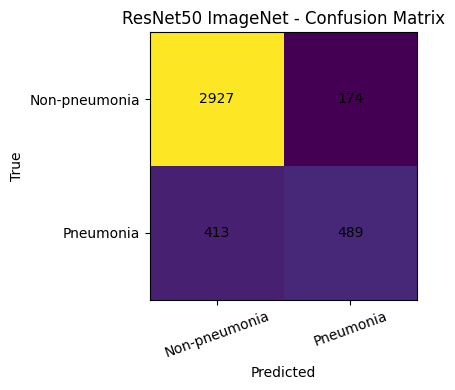

Saved: /kaggle/working/notebook02_baseline/figures/resnet50_confusion_matrix.png


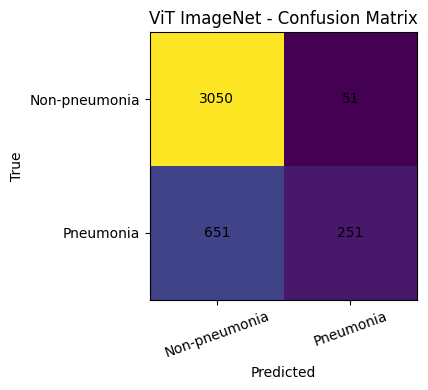

Saved: /kaggle/working/notebook02_baseline/figures/vit_confusion_matrix.png


In [26]:
# ============================================================
# CELL 26: VẼ CONFUSION MATRIX
# ============================================================

def plot_confusion_matrix_from_df(pred_df, title, save_path):
    y_true = pred_df["label"].astype(int).values
    y_pred = pred_df["pred"].astype(int).values
    
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks([0, 1], ["Non-pneumonia", "Pneumonia"], rotation=20)
    plt.yticks([0, 1], ["Non-pneumonia", "Pneumonia"])
    
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()
    
    print("Saved:", save_path)

plot_confusion_matrix_from_df(
    resnet_pred_df,
    title="ResNet50 ImageNet - Confusion Matrix",
    save_path=FIG_DIR / "resnet50_confusion_matrix.png"
)

plot_confusion_matrix_from_df(
    vit_pred_df,
    title="ViT ImageNet - Confusion Matrix",
    save_path=FIG_DIR / "vit_confusion_matrix.png"
)

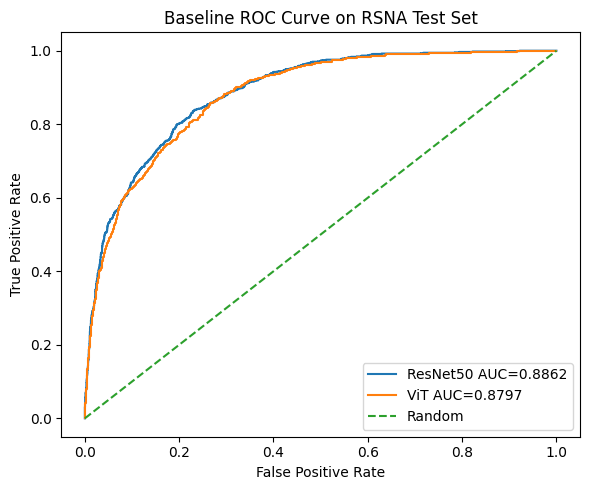

Saved: /kaggle/working/notebook02_baseline/figures/baseline_roc_curve.png


In [27]:
# ============================================================
# CELL 27: VẼ ROC CURVE SO SÁNH BASELINE
# ============================================================

from sklearn.metrics import roc_curve

def get_roc_data(pred_df):
    y_true = pred_df["label"].astype(int).values
    y_prob = pred_df["prob_pneumonia"].values
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    return fpr, tpr, auc

resnet_fpr, resnet_tpr, resnet_auc = get_roc_data(resnet_pred_df)
vit_fpr, vit_tpr, vit_auc = get_roc_data(vit_pred_df)

plt.figure(figsize=(6, 5))
plt.plot(resnet_fpr, resnet_tpr, label=f"ResNet50 AUC={resnet_auc:.4f}")
plt.plot(vit_fpr, vit_tpr, label=f"ViT AUC={vit_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline ROC Curve on RSNA Test Set")
plt.legend()
plt.tight_layout()

roc_path = FIG_DIR / "baseline_roc_curve.png"
plt.savefig(roc_path, dpi=200)
plt.show()

print("Saved:", roc_path)

In [28]:
# ============================================================
# CELL 28: NÉN OUTPUT NOTEBOOK 02
# ============================================================

zip_base = "/kaggle/working/notebook02_baseline"
shutil.make_archive(zip_base, "zip", OUTPUT_DIR)

print("Created:", zip_base + ".zip")

print("\nDanh sách file output:")
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print("-", p.relative_to(OUTPUT_DIR))

Created: /kaggle/working/notebook02_baseline.zip

Danh sách file output:
- baseline_metrics.csv
- checkpoints/resnet50_imagenet_best.pth
- checkpoints/vit_imagenet_best.pth
- figures/baseline_roc_curve.png
- figures/resnet50_confusion_matrix.png
- figures/vit_confusion_matrix.png
- predictions/resnet50_predictions.csv
- predictions/vit_predictions.csv
- resnet50_imagenet_train_history.csv
- vit_imagenet_train_history.csv
